In [1]:
from pathlib import Path
import copy
import random

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.ndimage import gaussian_filter
from sklearn.metrics import auc, roc_curve
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader

# Reproducibility and shared locations
SEED = 12345
N_STUDENTS_PER_SIZE = 5
STUDENT_SEEDS = [SEED + index for index in range(N_STUDENTS_PER_SIZE)]
REFERENCE_FPR = 0.01

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path("/pscratch/sd/m/mcohen54/rajat_data/saved_datasets")
MODEL_DIR = (
    Path("/pscratch/sd/m/mcohen54/rajat_data/trained_models")
    / "nn_students_more_additional_studies"
)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 512
INFERENCE_BATCH_SIZE = 8192
NUM_WORKERS = 4
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 8
SIGNAL_TAGS = ["Ato4l", "hChToTauNu", "hToTauTau", "leptoquark"]
SIGNAL_LABELS = {
    "Ato4l": r"$A \to 4\ell$",
    "hChToTauNu": r"$H^{\pm} \to \tau\nu$",
    "hToTauTau": r"$h \to \tau\tau$",
    "leptoquark": "Leptoquark",
}
TARGET_KEYS = {"KL": "KL_AD_scores", "MSE": "MSE_AD_scores"}

print(f"Using device: {DEVICE}")
print(f"Datasets: {DATA_DIR}")
print(f"Models:   {MODEL_DIR}")

Using device: cuda
Datasets: /pscratch/sd/m/mcohen54/rajat_data/saved_datasets
Models:   /pscratch/sd/m/mcohen54/rajat_data/trained_models/nn_students_more_additional_studies


In [2]:
def load_subdicts_from_h5(save_dir, tags_to_use=None):
    """Load each HDF5 file in ``save_dir`` into a nested dictionary."""
    save_dir = Path(save_dir)
    requested = set(tags_to_use) if tags_to_use is not None else None
    main_dict = {}

    if not save_dir.is_dir():
        raise FileNotFoundError(f"Dataset directory does not exist: {save_dir}")

    for file_path in sorted(save_dir.glob("*.h5")):
        tag = file_path.stem
        if requested is not None and tag not in requested:
            continue
        with h5py.File(file_path, "r") as handle:
            main_dict[tag] = {key: np.asarray(handle[key]) for key in handle}
        print(f"Loaded {tag} from {file_path}")

    if requested is not None:
        missing = requested.difference(main_dict)
        if missing:
            raise FileNotFoundError(f"Missing datasets for tags: {sorted(missing)}")
    return main_dict

In [3]:
required_tags = ["train", "val", "Background", *SIGNAL_TAGS]
datasets = load_subdicts_from_h5(DATA_DIR, tags_to_use=required_tags)

required_keys = {"data", *TARGET_KEYS.values()}
for tag, data_dict in datasets.items():
    missing = required_keys.difference(data_dict)
    if missing:
        raise KeyError(f"Dataset '{tag}' is missing keys: {sorted(missing)}")

Loaded Ato4l from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/Ato4l.h5
Loaded Background from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/Background.h5
Loaded hChToTauNu from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/hChToTauNu.h5
Loaded hToTauTau from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/hToTauTau.h5
Loaded leptoquark from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/leptoquark.h5
Loaded train from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/train.h5
Loaded val from /pscratch/sd/m/mcohen54/rajat_data/saved_datasets/val.h5


In [4]:
for tag, data_dict in datasets.items():
    print(f"Tag: {tag}")
    for key, value in data_dict.items():
        print(f"  {key}: {value.shape}")

Tag: Ato4l
  KL_AD_scores: (55969,)
  MSE_AD_scores: (55969,)
  clipped_KL_AD_scores: (55969,)
  data: (55969, 57)
  large_student_AD_scores: (55969,)
  medium_student_AD_scores: (55969,)
  small_student_AD_scores: (55969,)
Tag: Background
  KL_AD_scores: (200000,)
  MSE_AD_scores: (200000,)
  clipped_KL_AD_scores: (200000,)
  data: (200000, 57)
  large_student_AD_scores: (200000,)
  medium_student_AD_scores: (200000,)
  small_student_AD_scores: (200000,)
Tag: hChToTauNu
  KL_AD_scores: (760272,)
  MSE_AD_scores: (760272,)
  clipped_KL_AD_scores: (760272,)
  data: (760272, 57)
  large_student_AD_scores: (760272,)
  medium_student_AD_scores: (760272,)
  small_student_AD_scores: (760272,)
Tag: hToTauTau
  KL_AD_scores: (691283,)
  MSE_AD_scores: (691283,)
  clipped_KL_AD_scores: (691283,)
  data: (691283, 57)
  large_student_AD_scores: (691283,)
  medium_student_AD_scores: (691283,)
  small_student_AD_scores: (691283,)
Tag: leptoquark
  KL_AD_scores: (340544,)
  MSE_AD_scores: (340544,)


In [5]:
def plot_roc_curves(datasets, AD_score_type='MSE_AD_scores'):
    plt.figure(figsize=(8, 5))

    bkg_scores = datasets['Background'][AD_score_type]
    bkg_labels = np.zeros_like(bkg_scores)

    skip_tags = ['Background', 'train', 'val']

    for tag, data_dict in datasets.items():
        if tag in skip_tags: continue

        sig_scores = data_dict[AD_score_type]
        combined_scores = np.concatenate([bkg_scores, sig_scores])
        combined_labels = np.concatenate([bkg_labels, np.ones_like(sig_scores)])

        fpr, tpr, thresholds = roc_curve(y_true=combined_labels, y_score=combined_scores)
        roc_auc = auc(fpr, tpr)

        threshold_tpr = np.interp(REFERENCE_FPR, fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=fr'{tag} (AUC = {roc_auc:.2f}, $\epsilon_S$(0.01) = {threshold_tpr:.2e})',
            linewidth=2,
        )

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.axvline(x=REFERENCE_FPR, color='red', linestyle='--')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves: {AD_score_type}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

In [6]:
# Architecture grids used in the later studies. The current configurations
# (32) and (64, 32) are retained as baselines alongside the requested variants.
MEDIUM_WIDTHS = [1, 4, 8, 16, 32, 64]
LARGE_WIDTHS = [(4, 32), (16, 16), (16, 32), (32, 32), (64, 32), (64, 64)]

In [7]:
class StudentNetSmall(nn.Module):
    def __init__(self, input_dim=57):
        super(StudentNetSmall, self).__init__()
        # Just one Linear layer: [input_dim] → [1]
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        # x: (batch_size, 57)
        out = self.fc(x)  # → (batch_size, 1)
        return out


# -- Medium network: one hidden layer --
class StudentNetMedium(nn.Module):
    def __init__(self, input_dim=57, hidden_dim=64):
        super(StudentNetMedium, self).__init__()
        # Linear → ReLU → Linear
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch_size, 57)
        h = self.act(self.fc1(x))  # → (batch_size, hidden_dim)
        out = self.fc2(h)          # → (batch_size, 1)
        return out


# -- Large network: two hidden layers --
class StudentNetLarge(nn.Module):
    def __init__(self, input_dim=57, hidden1=128, hidden2=64):
        super(StudentNetLarge, self).__init__()
        # Linear → ReLU → Linear → ReLU → Linear
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.act1 = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.act2 = nn.ReLU(inplace=True)
        self.fc3 = nn.Linear(hidden2, 1)

    def forward(self, x):
        # x: (batch_size, 57)
        h1 = self.act1(self.fc1(x))  # → (batch_size, hidden1)
        h2 = self.act2(self.fc2(h1)) # → (batch_size, hidden2)
        out = self.fc3(h2)           # → (batch_size, 1)
        return out

In [8]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from typing import Optional, Dict, Any
import os


class Trainer:
    """
    Trainer class for regression models (e.g., StudentNetSmall/Medium/Large) in PyTorch.
    Handles training, validation, checkpointing, and learning‐rate scheduling.
    """

    def __init__(
        self,
        model: nn.Module,
        train_loader: torch.utils.data.DataLoader,
        val_loader: torch.utils.data.DataLoader,
        device: Optional[torch.device] = None,
        lr: float = 1e-3,
        weight_decay: float = 0.0,
        scheduler_params: Optional[Dict[str, Any]] = None,
        checkpoint_dir: str = "./checkpoints",
    ):
        """
        Args:
            model:             The PyTorch model to train.
            train_loader:      DataLoader for the training set. Batches should yield (features, targets).
            val_loader:        DataLoader for the validation set. Batches should yield (features, targets).
            device:            torch.device (e.g., torch.device("cuda") or torch.device("cpu")).
                               If None, defaults to "cuda" if available, else "cpu".
            lr:                Initial learning rate for Adam.
            weight_decay:      Weight‐decay (L2 penalty) for Adam.
            scheduler_params:  Dict of parameters for ReduceLROnPlateau scheduler.
                               Keys may include "mode", "factor", "patience", "min_lr", etc.
                               If None, defaults to {"mode": "min", "factor": 0.5, "patience": 5, "min_lr": 1e-6}.
            checkpoint_dir:    Directory where best‐model checkpoints and logs will be saved.
        """
        # Device setup
        if device is None:
            self.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        else:
            self.device = device

        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader

        # Loss function
        self.criterion = nn.MSELoss()

        # Optimizer
        self.optimizer = Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)

        # LR Scheduler (ReduceLROnPlateau)
        default_sched = {"mode": "min", "factor": 0.5, "patience": 5, "min_lr": 1e-6, "verbose": True}
        sched_params = scheduler_params or default_sched
        self.scheduler = ReduceLROnPlateau(self.optimizer, **sched_params)

        # Checkpoint directory
        os.makedirs(checkpoint_dir, exist_ok=True)
        self.checkpoint_dir = checkpoint_dir

        # Internal bookkeeping
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "lr": [],
        }
        self.best_val_loss = float("inf")
        self.best_epoch = -1

    def train_epoch(self) -> float:
        """
        Runs one full training epoch.
        Returns:
            Average training loss over all batches in this epoch.
        """
        self.model.train()
        running_loss = 0.0
        total_samples = 0

        for batch in self.train_loader:
            # Assume batch is (features, targets)
            x_batch, y_batch = batch
            x_batch = x_batch.to(self.device, dtype=torch.float32)
            y_batch = y_batch.to(self.device, dtype=torch.float32).view(-1, 1)

            # Zero gradients
            self.optimizer.zero_grad()

            # Forward pass
            preds = self.model(x_batch)
            loss = self.criterion(preds, y_batch)

            # Backward + optimize
            loss.backward()
            self.optimizer.step()

            # Accumulate
            batch_size = x_batch.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

        avg_loss = running_loss / total_samples
        return avg_loss

    def validate(self) -> float:
        """
        Runs one full validation pass (no gradient computation).
        Returns:
            Average validation loss over all batches in the validation set.
        """
        self.model.eval()
        running_loss = 0.0
        total_samples = 0

        with torch.no_grad():
            for batch in self.val_loader:
                x_batch, y_batch = batch
                x_batch = x_batch.to(self.device, dtype=torch.float32)
                y_batch = y_batch.to(self.device, dtype=torch.float32).view(-1, 1)

                preds = self.model(x_batch)
                loss = self.criterion(preds, y_batch)

                batch_size = x_batch.size(0)
                running_loss += loss.item() * batch_size
                total_samples += batch_size

        avg_loss = running_loss / total_samples
        return avg_loss

    def fit(self, num_epochs: int, print_every: int = 1):
        """
        Full training loop over `num_epochs` epochs, performing training, validation,
        LR scheduling, and checkpointing.

        Args:
            num_epochs: Number of epochs to train.
            print_every: Print progress every `print_every` epochs.
        """
        for epoch in range(1, num_epochs + 1):
            # ---- TRAIN ----
            train_loss = self.train_epoch()

            # ---- VALIDATE ----
            val_loss = self.validate()

            # ---- LR SCHEDULER STEP ----
            # For ReduceLROnPlateau, step with validation loss:
            self.scheduler.step(val_loss)

            # ---- LOGGING ----
            current_lr = self.optimizer.param_groups[0]["lr"]
            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["lr"].append(current_lr)

            if epoch % print_every == 0:
                print(
                    f"Epoch {epoch:3d} | "
                    f"Train Loss: {train_loss:.6f} | "
                    f"Val Loss: {val_loss:.6f} | "
                    f"LR: {current_lr:.2e}"
                )

        print(f"\nTraining complete. Best val_loss={self.best_val_loss:.6f} at epoch {self.best_epoch}.")



In [9]:
class ADRegressionDataset(Dataset):
    """
    A PyTorch Dataset that takes two NumPy arrays:
      - features: shape (N, 57)
      - targets:  shape (N,)
    and returns (feature_tensor, target_tensor) per __getitem__.
    """
    def __init__(self, features: np.ndarray, targets: np.ndarray):
        assert features.shape[0] == targets.shape[0], "Number of rows must match"
        self.features = features.astype(np.float32)
        self.targets = targets.astype(np.float32)

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        x = self.features[idx]          # shape (57,)
        y = self.targets[idx]           # scalar
        return torch.from_numpy(x), torch.tensor(y).view(-1, 1)

In [10]:
# DataLoaders are built separately for KL and MSE by make_loaders() below.
# Keeping construction target-specific prevents accidentally training an MSE
# student against the KL target (or vice versa).

In [11]:
BASE_ARCHITECTURES = {
    "small": (StudentNetSmall, {}),
    "medium": (StudentNetMedium, {"hidden_dim": 32}),
    "large": (StudentNetLarge, {"hidden1": 64, "hidden2": 32}),
}


def _set_training_seed(seed):
    """Seed initialization and data ordering for one independent student."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_loaders(target_key, seed=SEED):
    train_data = ADRegressionDataset(datasets["train"]["data"], datasets["train"][target_key])
    val_data = ADRegressionDataset(datasets["val"]["data"], datasets["val"][target_key])
    common = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": DEVICE.type == "cuda",
    }
    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_data, shuffle=True, generator=generator, **common)
    val_loader = DataLoader(val_data, shuffle=False, **common)
    return train_loader, val_loader


def _load_checkpoint(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:  # PyTorch < 2.0
        return torch.load(path, map_location=DEVICE)


def train_or_load_model(
    model_class, model_kwargs, target_name, model_id, mode,
    seed=SEED, study_name="base",
):
    """Train/load one seeded student and keep its checkpoint in a structured directory."""
    mode = mode.lower()
    if mode not in {"train", "load"}:
        raise ValueError("mode must be either 'train' or 'load'")

    _set_training_seed(seed)
    target_key = TARGET_KEYS[target_name]
    full_kwargs = {"input_dim": datasets["train"]["data"].shape[-1], **model_kwargs}
    model = model_class(**full_kwargs).to(DEVICE)
    checkpoint_path = (
        MODEL_DIR / target_name.lower() / study_name / model_id / f"seed_{seed}.pt"
    )

    if mode == "load":
        if not checkpoint_path.is_file():
            raise FileNotFoundError(
                f"No saved model at {checkpoint_path}. Set this study's mode to 'train' first."
            )
        checkpoint = _load_checkpoint(checkpoint_path)
        model.load_state_dict(checkpoint["state_dict"])
        model.eval()
        print(f"Loaded {model_id}, seed {seed} ({target_name}) from {checkpoint_path}")
        return model

    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    train_loader, val_loader = make_loaders(target_key, seed=seed)
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)
    criterion = nn.MSELoss()
    best_loss = np.inf
    best_state = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": []}

    print(f"\nTraining {model_id}, seed {seed} against {target_name}")
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        train_sum = 0.0
        train_count = 0
        for features, targets in train_loader:
            features = features.to(DEVICE, dtype=torch.float32, non_blocking=True)
            targets = targets.to(DEVICE, dtype=torch.float32).view(-1, 1)
            optimizer.zero_grad(set_to_none=True)
            predictions = model(features)
            loss = criterion(predictions, targets)
            loss.backward()
            optimizer.step()
            train_sum += loss.item() * features.shape[0]
            train_count += features.shape[0]

        model.eval()
        val_sum = 0.0
        val_count = 0
        with torch.no_grad():
            for features, targets in val_loader:
                features = features.to(DEVICE, dtype=torch.float32, non_blocking=True)
                targets = targets.to(DEVICE, dtype=torch.float32).view(-1, 1)
                loss = criterion(model(features), targets)
                val_sum += loss.item() * features.shape[0]
                val_count += features.shape[0]

        train_loss = train_sum / train_count
        val_loss = val_sum / val_count
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)
        print(
            f"Epoch {epoch:02d} | train={train_loss:.6g} | val={val_loss:.6g} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"Early stopping after {epoch} epochs")
                break

    model.load_state_dict(best_state)
    model.eval()
    torch.save(
        {
            "state_dict": best_state,
            "model_kwargs": full_kwargs,
            "target_name": target_name,
            "target_key": target_key,
            "seed": seed,
            "study_name": study_name,
            "model_id": model_id,
            "best_val_loss": best_loss,
            "history": history,
        },
        checkpoint_path,
    )
    print(f"Saved best model (val={best_loss:.6g}) to {checkpoint_path}")
    return model


def predict_in_batches(model, features):
    predictions = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(features), INFERENCE_BATCH_SIZE):
            batch = torch.as_tensor(
                features[start:start + INFERENCE_BATCH_SIZE], dtype=torch.float32, device=DEVICE
            )
            predictions.append(model(batch).squeeze(-1).cpu().numpy())
    return np.concatenate(predictions)


def collect_scores(model, tags=("Background", *SIGNAL_TAGS)):
    return {tag: predict_in_batches(model, datasets[tag]["data"]) for tag in tags}


def run_base_study(mode):
    models = {target: {} for target in TARGET_KEYS}
    scores = {target: {} for target in TARGET_KEYS}
    for target_name in TARGET_KEYS:
        for size_name, (model_class, kwargs) in BASE_ARCHITECTURES.items():
            model_id = f"base_{size_name}"
            model = train_or_load_model(model_class, kwargs, target_name, model_id, mode)
            models[target_name][size_name] = model
            scores[target_name][size_name] = collect_scores(model)
    return models, scores


def run_size_study(mode, target_name="KL"):
    """Train/load five independent students for every width-scan architecture.

    ``scores[family][architecture]`` is a five-element list; each element maps
    dataset tags to one independently trained student's predictions.
    """
    if target_name != "KL":
        raise ValueError("The student-size study is configured to regress KL_AD_scores only.")

    models = {"medium": {}, "large": {}}
    scores = {"medium": {}, "large": {}}

    configurations = {
        "medium": [
            (str(width), StudentNetMedium, {"hidden_dim": width}, f"width_{width}")
            for width in MEDIUM_WIDTHS
        ],
        "large": [
            (
                f"({hidden1}, {hidden2})",
                StudentNetLarge,
                {"hidden1": hidden1, "hidden2": hidden2},
                f"widths_{hidden1}x{hidden2}",
            )
            for hidden1, hidden2 in LARGE_WIDTHS
        ],
    }

    for family, family_configs in configurations.items():
        for label, model_class, kwargs, model_id in family_configs:
            models[family][label] = []
            scores[family][label] = []
            for student_index, seed in enumerate(STUDENT_SEEDS, start=1):
                model = train_or_load_model(
                    model_class,
                    kwargs,
                    target_name,
                    model_id,
                    mode,
                    seed=seed,
                    study_name=f"size_scan/{family}",
                )
                scores[family][label].append(collect_scores(model))
                models[family][label].append(model.cpu())
                if DEVICE.type == "cuda":
                    torch.cuda.empty_cache()
                print(
                    f"Completed {family} {label}: student "
                    f"{student_index}/{N_STUDENTS_PER_SIZE}"
                )

    return models, scores


In [12]:
for tag, data_dict in datasets.items():
    print(f"Tag: {tag}")
    for key, value in data_dict.items():
        print(f"  {key}: {value.shape}")

Tag: Ato4l
  KL_AD_scores: (55969,)
  MSE_AD_scores: (55969,)
  clipped_KL_AD_scores: (55969,)
  data: (55969, 57)
  large_student_AD_scores: (55969,)
  medium_student_AD_scores: (55969,)
  small_student_AD_scores: (55969,)
Tag: Background
  KL_AD_scores: (200000,)
  MSE_AD_scores: (200000,)
  clipped_KL_AD_scores: (200000,)
  data: (200000, 57)
  large_student_AD_scores: (200000,)
  medium_student_AD_scores: (200000,)
  small_student_AD_scores: (200000,)
Tag: hChToTauNu
  KL_AD_scores: (760272,)
  MSE_AD_scores: (760272,)
  clipped_KL_AD_scores: (760272,)
  data: (760272, 57)
  large_student_AD_scores: (760272,)
  medium_student_AD_scores: (760272,)
  small_student_AD_scores: (760272,)
Tag: hToTauTau
  KL_AD_scores: (691283,)
  MSE_AD_scores: (691283,)
  clipped_KL_AD_scores: (691283,)
  data: (691283, 57)
  large_student_AD_scores: (691283,)
  medium_student_AD_scores: (691283,)
  small_student_AD_scores: (691283,)
Tag: leptoquark
  KL_AD_scores: (340544,)
  MSE_AD_scores: (340544,)



Training base_small, seed 12345 against KL
Epoch 01 | train=9.87249 | val=5.34 | lr=1.00e-03
Epoch 02 | train=7.51284 | val=5.1346 | lr=1.00e-03
Epoch 03 | train=7.39502 | val=5.03614 | lr=1.00e-03
Epoch 04 | train=7.36383 | val=5.01485 | lr=1.00e-03
Epoch 05 | train=7.41868 | val=5.02768 | lr=1.00e-03
Epoch 06 | train=7.37484 | val=5.08804 | lr=1.00e-03
Epoch 07 | train=7.40754 | val=5.37433 | lr=1.00e-03
Epoch 08 | train=7.3755 | val=6.40628 | lr=5.00e-04
Epoch 09 | train=7.28949 | val=5.05797 | lr=5.00e-04
Epoch 10 | train=7.28867 | val=5.04245 | lr=5.00e-04
Epoch 11 | train=7.27614 | val=5.09349 | lr=5.00e-04
Epoch 12 | train=7.26313 | val=5.16769 | lr=2.50e-04
Early stopping after 12 epochs
Saved best model (val=5.01485) to /pscratch/sd/m/mcohen54/rajat_data/trained_models/nn_students_more_additional_studies/kl/base/base_small/seed_12345.pt

Training base_medium, seed 12345 against KL
Epoch 01 | train=6.16136 | val=3.83215 | lr=1.00e-03
Epoch 02 | train=5.04828 | val=3.74591 | lr

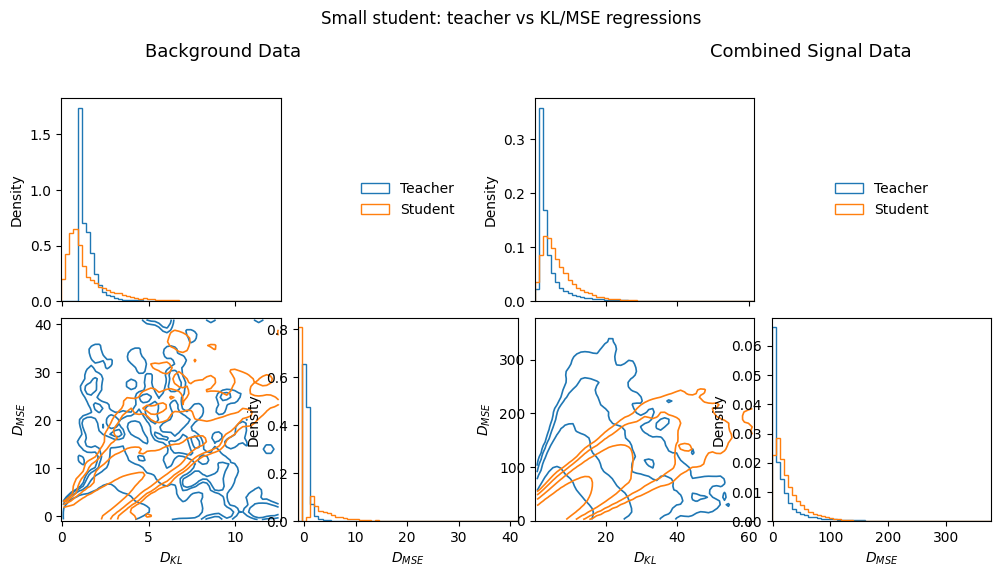

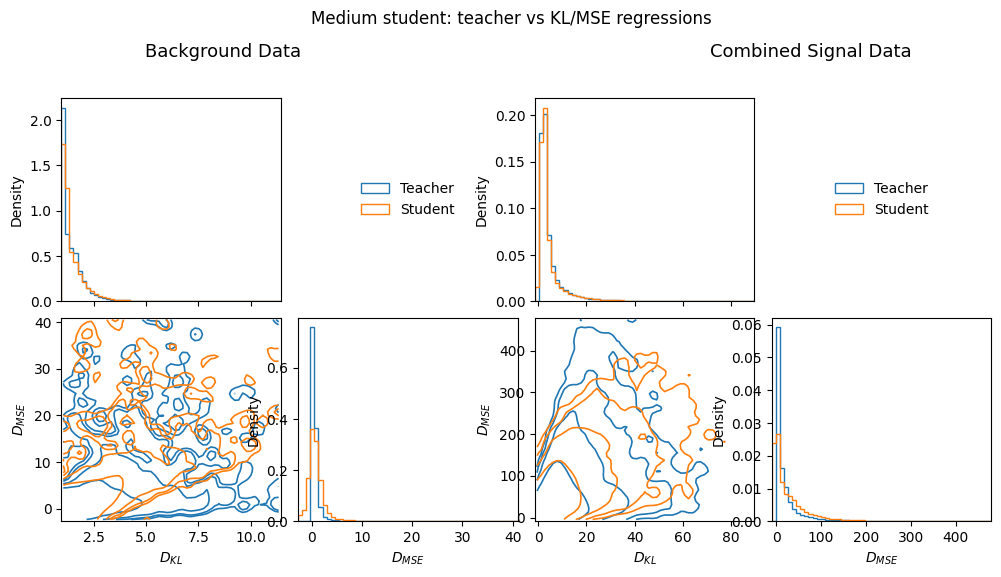

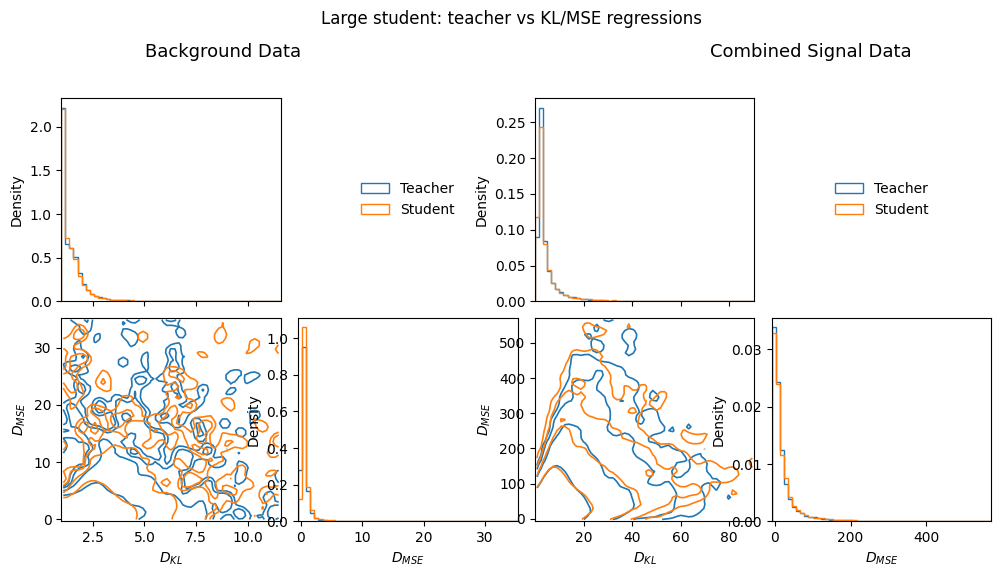

In [31]:
# STUDY 1 FLAG: choose "train" to fit and save all six students, or
# "load" to restore them from MODEL_DIR.
STUDY_1_MODE = "train"

base_models, base_scores = run_base_study(STUDY_1_MODE)


def _subsample_joint(x, y, max_points, seed):
    x = np.asarray(x)
    y = np.asarray(y)
    finite = np.isfinite(x) & np.isfinite(y)
    indices = np.flatnonzero(finite)
    if len(indices) > max_points:
        rng = np.random.default_rng(seed)
        indices = rng.choice(indices, size=max_points, replace=False)
    return x[indices], y[indices]


def _joint_scores(size_name, tags, max_points_per_tag=25_000):
    teacher_x, teacher_y, student_x, student_y = [], [], [], []
    for tag_index, tag in enumerate(tags):
        tx, ty = _subsample_joint(
            datasets[tag][TARGET_KEYS["KL"]], datasets[tag][TARGET_KEYS["MSE"]],
            max_points_per_tag, SEED + tag_index,
        )
        sx, sy = _subsample_joint(
            base_scores["KL"][size_name][tag], base_scores["MSE"][size_name][tag],
            max_points_per_tag, SEED + tag_index,
        )
        teacher_x.append(tx)
        teacher_y.append(ty)
        student_x.append(sx)
        student_y.append(sy)
    return tuple(np.concatenate(values) for values in (teacher_x, teacher_y, student_x, student_y))


def _draw_density_contour(ax, x, y, color, x_limits, y_limits):
    density, x_edges, y_edges = np.histogram2d(
        x, y, bins=55, range=[x_limits, y_limits], density=True
    )
    density = gaussian_filter(density, sigma=1.2)
    positive = density[density > 0]
    if positive.size == 0:
        return
    levels = np.unique(np.quantile(positive, [0.55, 0.72, 0.86, 0.95]))
    if levels.size:
        x_centers = (x_edges[:-1] + x_edges[1:]) / 2
        y_centers = (y_edges[:-1] + y_edges[1:]) / 2
        ax.contour(x_centers, y_centers, density.T, levels=levels, colors=color, linewidths=1.2)


def plot_teacher_student_corner(size_name):
    groups = [
        ("Background Data", ["Background"]),
        ("Combined Signal Data", SIGNAL_TAGS),
    ]
    fig = plt.figure(figsize=(12, 5.5))
    grid = fig.add_gridspec(2, 4, hspace=0.08, wspace=0.08)

    for group_index, (group_title, tags) in enumerate(groups):
        tx, ty, sx, sy = _joint_scores(size_name, tags)
        x_limits = np.nanpercentile(np.concatenate([tx, sx]), [0.5, 99.5])
        y_limits = np.nanpercentile(np.concatenate([ty, sy]), [0.5, 99.5])
        x_bins = np.linspace(*x_limits, 55)
        y_bins = np.linspace(*y_limits, 55)
        column = group_index * 2

        ax_kl = fig.add_subplot(grid[0, column])
        ax_joint = fig.add_subplot(grid[1, column])
        ax_mse = fig.add_subplot(grid[1, column + 1])
        ax_legend = fig.add_subplot(grid[0, column + 1])
        ax_legend.axis("off")

        ax_kl.hist(tx, bins=x_bins, density=True, histtype="step", color="tab:blue", label="Teacher")
        ax_kl.hist(sx, bins=x_bins, density=True, histtype="step", color="tab:orange", label="Student")
        ax_mse.hist(ty, bins=y_bins, density=True, histtype="step", color="tab:blue")
        ax_mse.hist(sy, bins=y_bins, density=True, histtype="step", color="tab:orange")
        _draw_density_contour(ax_joint, tx, ty, "tab:blue", x_limits, y_limits)
        _draw_density_contour(ax_joint, sx, sy, "tab:orange", x_limits, y_limits)

        ax_kl.set_xlim(x_limits)
        ax_joint.set_xlim(x_limits)
        ax_joint.set_ylim(y_limits)
        ax_mse.set_xlim(y_limits)
        ax_kl.set_xticklabels([])
        ax_joint.set_xlabel(r"$D_{KL}$")
        ax_joint.set_ylabel(r"$D_{MSE}$")
        ax_mse.set_xlabel(r"$D_{MSE}$")
        ax_kl.set_ylabel("Density")
        ax_mse.set_ylabel("Density")
        ax_legend.legend(*ax_kl.get_legend_handles_labels(), loc="center", frameon=False)
        fig.text(0.26 + 0.49 * group_index, 0.98, group_title, ha="center", va="top", fontsize=13)

    fig.suptitle(f"{size_name.capitalize()} student: teacher vs KL/MSE regressions", y=1.04)
    plt.show()


for student_size in ("small", "medium", "large"):
    plot_teacher_student_corner(student_size)

In [13]:
def plot_stacked_teacher_student_corners():
    """One figure: (a) small, (b) medium, (c) large.
    Background and signal panels share axis limits within each size.
    """
    sizes = ("small", "medium", "large")
    panel_labels = ("(a)", "(b)", "(c)")
    groups = [
        ("Background Data", ["Background"]),
        ("Combined Signal Data", SIGNAL_TAGS),
    ]

    n_sizes = len(sizes)
    fig = plt.figure(figsize=(12, 5.2 * n_sizes))
    outer = fig.add_gridspec(n_sizes, 1, hspace=0.28)

    for size_index, (size_name, panel_label) in enumerate(zip(sizes, panel_labels)):
        inner = outer[size_index].subgridspec(
            2, 4,
            hspace=0.10,
            wspace=0.10,
        )

        # ------------------------------------------------------------
        # First collect BOTH background + signal scores for this size
        # so that they can use identical axis limits.
        # ------------------------------------------------------------
        group_scores = []

        for group_title, tags in groups:
            tx, ty, sx, sy = _joint_scores(size_name, tags)
            group_scores.append((group_title, tx, ty, sx, sy))

        # Shared KL limits across background + signals
        all_kl = np.concatenate([
            arr
            for _, tx, _, sx, _ in group_scores
            for arr in (tx, sx)
        ])

        # Shared MSE limits across background + signals
        all_mse = np.concatenate([
            arr
            for _, _, ty, _, sy in group_scores
            for arr in (ty, sy)
        ])

        x_limits = np.nanpercentile(all_kl, [0.5, 99.5])
        y_limits = np.nanpercentile(all_mse, [0.5, 99.5])

        x_bins = np.linspace(*x_limits, 55)
        y_bins = np.linspace(*y_limits, 55)

        # ------------------------------------------------------------
        # Plot each group using the SAME limits
        # ------------------------------------------------------------
        for group_index, (group_title, tx, ty, sx, sy) in enumerate(group_scores):
            column = group_index * 2

            ax_kl = fig.add_subplot(inner[0, column])
            ax_joint = fig.add_subplot(inner[1, column])
            ax_mse = fig.add_subplot(inner[1, column + 1])
            ax_legend = fig.add_subplot(inner[0, column + 1])
            ax_legend.axis("off")

            # KL distributions
            ax_kl.hist(
                tx,
                bins=x_bins,
                density=True,
                histtype="step",
                color="tab:blue",
                label="Teacher",
            )
            ax_kl.hist(
                sx,
                bins=x_bins,
                density=True,
                histtype="step",
                color="tab:orange",
                label="Student",
            )

            # MSE distributions
            ax_mse.hist(
                ty,
                bins=y_bins,
                density=True,
                histtype="step",
                color="tab:blue",
            )
            ax_mse.hist(
                sy,
                bins=y_bins,
                density=True,
                histtype="step",
                color="tab:orange",
            )

            # Joint density contours
            _draw_density_contour(
                ax_joint,
                tx,
                ty,
                "tab:blue",
                x_limits,
                y_limits,
            )
            _draw_density_contour(
                ax_joint,
                sx,
                sy,
                "tab:orange",
                x_limits,
                y_limits,
            )

            # Shared limits
            ax_kl.set_xlim(x_limits)

            ax_joint.set_xlim(x_limits)
            ax_joint.set_ylim(y_limits)

            # MSE histogram is rotated conceptually, so its x-axis
            # corresponds to the joint plot's MSE/y-axis.
            ax_mse.set_xlim(y_limits)

            ax_kl.set_xticklabels([])
            ax_joint.set_xlabel(r"$D_{KL}$")
            ax_mse.set_xlabel(r"$D_{MSE}$")

            leftmost = group_index == 0

            # Bottom-right histogram: never show y tick labels
            ax_mse.tick_params(axis="y", labelleft=False)
            
            if leftmost:
                ax_kl.set_ylabel("Density")
                ax_joint.set_ylabel(r"$D_{MSE}$")
            
                ax_legend.legend(
                    *ax_kl.get_legend_handles_labels(),
                    loc="center",
                    frameon=False,
                )
            else:
                ax_kl.tick_params(labelleft=False)
                ax_joint.tick_params(labelleft=False)

            if size_index == 0:
                fig.text(
                    0.26 + 0.49 * group_index,
                    0.955,
                    group_title,
                    ha="center",
                    va="top",
                    fontsize=13,
                )

        # Size name to the left of the (a)/(b)/(c) block
        fig.text(
            0.02,
            0.82 - 0.31 * size_index,
            size_name.capitalize(),
            rotation=90,
            ha="center",
            va="center",
            fontsize=12,
        )

    fig.suptitle(
        "Teacher vs KL/MSE student regressions",
        y=0.995,
    )

    plt.show()


plot_stacked_teacher_student_corners()

NameError: name '_joint_scores' is not defined

<Figure size 1200x1560 with 0 Axes>

In [28]:
from matplotlib.lines import Line2D


ROC_FPR_GRID = np.logspace(-6, 0, 500)


def _roc_values(background_scores, signal_scores):
    labels = np.concatenate([
        np.zeros(len(background_scores), dtype=np.int8),
        np.ones(len(signal_scores), dtype=np.int8),
    ])
    scores = np.concatenate([background_scores, signal_scores])
    fpr, tpr, _ = roc_curve(labels, scores)
    return fpr, tpr, auc(fpr, tpr)


def _architecture_size(family, label):
    if family == "medium":
        return int(label)
    hidden1, hidden2 = (int(value.strip()) for value in label.strip("()").split(","))
    return 58 * hidden1 + hidden1 * hidden2 + 2 * hidden2 + 1


def _ordered_architectures(family, architecture_scores, largest_first=True):
    return sorted(
        architecture_scores,
        key=lambda label: _architecture_size(family, label),
        reverse=largest_first,
    )


def _student_roc_summary(replicate_scores, signal_tag):
    interpolated_tprs = []
    aucs = []
    efficiencies = []
    for scores_by_tag in replicate_scores:
        fpr, tpr, roc_auc = _roc_values(
            scores_by_tag["Background"], scores_by_tag[signal_tag]
        )
        interpolated_tprs.append(np.interp(ROC_FPR_GRID, fpr, tpr))
        aucs.append(roc_auc)
        efficiencies.append(np.interp(REFERENCE_FPR, fpr, tpr))

    tprs = np.asarray(interpolated_tprs)
    return {
        "mean_tpr": tprs.mean(axis=0),
        "std_tpr": tprs.std(axis=0),
        "aucs": np.asarray(aucs),
        "efficiencies": np.asarray(efficiencies),
    }


def _style_roc_axis(ax, signal_tag, show_ylabel=True):
    ax.plot(ROC_FPR_GRID, ROC_FPR_GRID, color="0.65", linestyle=":", linewidth=1)
    ax.axvline(REFERENCE_FPR, color="0.55", linestyle=":", linewidth=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e-6, 1)
    ax.set_ylim(1e-4, 1)
    ax.set_xlabel("FPR")
    if show_ylabel:
        ax.set_ylabel("TPR")
    ax.set_title(SIGNAL_LABELS.get(signal_tag, signal_tag))
    ax.grid(True, which="major", alpha=0.2)


def _plot_roc_family_on_axis(ax, size_scores, target_name, family, signal_tag, colors, include_teacher):
    summaries = {}
    architecture_order = _ordered_architectures(family, size_scores[family])
    for architecture in architecture_order:
        summary = _student_roc_summary(size_scores[family][architecture], signal_tag)
        summaries[architecture] = summary
        mean_tpr = summary["mean_tpr"]
        std_tpr = summary["std_tpr"]
        color = colors[architecture]
        ax.plot(ROC_FPR_GRID, mean_tpr, color=color, linewidth=1.7)
        ax.fill_between(
            ROC_FPR_GRID,
            np.clip(mean_tpr - std_tpr, 1e-7, 1),
            np.clip(mean_tpr + std_tpr, 1e-7, 1),
            color=color,
            alpha=0.16,
            linewidth=0,
        )

    if include_teacher:
        teacher_key = TARGET_KEYS[target_name]
        teacher_fpr, teacher_tpr, _ = _roc_values(
            datasets["Background"][teacher_key], datasets[signal_tag][teacher_key]
        )
        positive = (teacher_fpr > 0) & (teacher_tpr > 0)
        ax.plot(teacher_fpr[positive], teacher_tpr[positive], color="black", linewidth=2.0)

    return summaries


def _roc_legend_handles(family, architecture_order, colors, include_teacher):
    handles = []
    if include_teacher:
        handles.append(Line2D([0], [0], color="black", linewidth=2, label=r"$D_{KL}$ (teacher)"))
    handles.extend(
        Line2D(
            [0], [0], color=colors[architecture], linewidth=2,
            label=rf"$\widehat{{D}}_{{KL}}^{{{architecture}}}$",
        )
        for architecture in architecture_order
    )
    handles.append(Line2D([0], [0], color="0.65", linestyle=":", label="random"))
    return handles


def plot_individual_size_rocs(size_scores, target_name, family, include_teacher=True):
    """Make four standalone signal plots with mean ROC ± one seed-to-seed standard deviation."""
    architecture_order = _ordered_architectures(family, size_scores[family])
    palette = plt.cm.viridis(np.linspace(0.08, 0.9, len(architecture_order)))
    colors = dict(zip(architecture_order, palette))

    for signal_tag in SIGNAL_TAGS:
        fig, ax = plt.subplots(figsize=(9.5, 6.2))
        summaries = _plot_roc_family_on_axis(
            ax, size_scores, target_name, family, signal_tag, colors, include_teacher
        )
        _style_roc_axis(ax, signal_tag)
        handles = _roc_legend_handles(family, architecture_order, colors, include_teacher)
        labels = [handle.get_label() for handle in handles]
        for index, architecture in enumerate(architecture_order, start=int(include_teacher)):
            summary = summaries[architecture]
            labels[index] += (
                f"  AUC {summary['aucs'].mean():.3f}±{summary['aucs'].std():.3f}; "
                f"ε(0.01) {summary['efficiencies'].mean():.3f}±"
                f"{summary['efficiencies'].std():.3f}"
            )
        ax.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
        fig.suptitle(f"{family.capitalize()} KL students: mean ROC ± 1σ across five trainings")
        fig.tight_layout()
        plt.show()


def plot_combined_size_rocs(size_scores, target_name, family, include_teacher=True):
    """Place all four signals side by side with a shared teacher/student legend."""
    architecture_order = _ordered_architectures(family, size_scores[family])
    palette = plt.cm.viridis(np.linspace(0.08, 0.9, len(architecture_order)))
    colors = dict(zip(architecture_order, palette))
    fig, axes = plt.subplots(1, len(SIGNAL_TAGS), figsize=(20, 4.8), sharex=True, sharey=True)

    for index, (ax, signal_tag) in enumerate(zip(axes, SIGNAL_TAGS)):
        _plot_roc_family_on_axis(
            ax, size_scores, target_name, family, signal_tag, colors, include_teacher
        )
        _style_roc_axis(ax, signal_tag, show_ylabel=index == 0)

    handles = _roc_legend_handles(family, architecture_order, colors, include_teacher)
    legend = fig.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(0.89, 0.57),
        frameon=False,
        fontsize=14,
        #title="Teacher and students",
    )
    legend._legend_box.align = "left"
    # fig.text(0.967, 0.69, "Smaller", rotation=90, ha="center", va="center", fontsize=9)
    # axes[-1].annotate(
    #     "",
    #     xy=(1.19, 0.29),
    #     xytext=(1.19, 0.61),
    #     xycoords="axes fraction",
    #     arrowprops={"arrowstyle": "-|>", "color": "black", "lw": 1.1},
    #     annotation_clip=False,
    # )
    fig.suptitle(
        f"{family.capitalize()} KL student-size study: mean ROC ± 1σ across five trainings",
        y=1.02,
    )
    fig.subplots_adjust(left=0.06, right=0.87, bottom=0.16, top=0.84, wspace=0.12)
    plt.show()


def plot_size_rocs(size_scores, target_name, include_teacher=True):
    for family in ("medium", "large"):
        plot_individual_size_rocs(size_scores, target_name, family, include_teacher)
        plot_combined_size_rocs(size_scores, target_name, family, include_teacher)

In [14]:
# Model predictions are kept in memory; the source HDF5 datasets are not rewritten.
# Size-study checkpoints are organized as:
# MODEL_DIR / "kl" / "size_scan" / family / architecture / "seed_<seed>.pt".

## Study 2 — five-training hidden-width scans and ROC comparisons

Every medium and large width is trained five times with independent initialization and data-order seeds. The students regress the scalar `KL_AD_scores` target using pointwise MSE loss. ROC curves report the mean and one standard deviation across the five trainings at fixed architecture.

Loaded width_1, seed 12345 (KL) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/nn_students_more_additional_studies/kl/size_scan/medium/width_1/seed_12345.pt
Completed medium 1: student 1/5
Loaded width_1, seed 12346 (KL) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/nn_students_more_additional_studies/kl/size_scan/medium/width_1/seed_12346.pt
Completed medium 1: student 2/5
Loaded width_1, seed 12347 (KL) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/nn_students_more_additional_studies/kl/size_scan/medium/width_1/seed_12347.pt
Completed medium 1: student 3/5
Loaded width_1, seed 12348 (KL) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/nn_students_more_additional_studies/kl/size_scan/medium/width_1/seed_12348.pt
Completed medium 1: student 4/5
Loaded width_1, seed 12349 (KL) from /pscratch/sd/m/mcohen54/rajat_data/trained_models/nn_students_more_additional_studies/kl/size_scan/medium/width_1/seed_12349.pt
Completed medium 1: student 5/5
Loaded width_4,

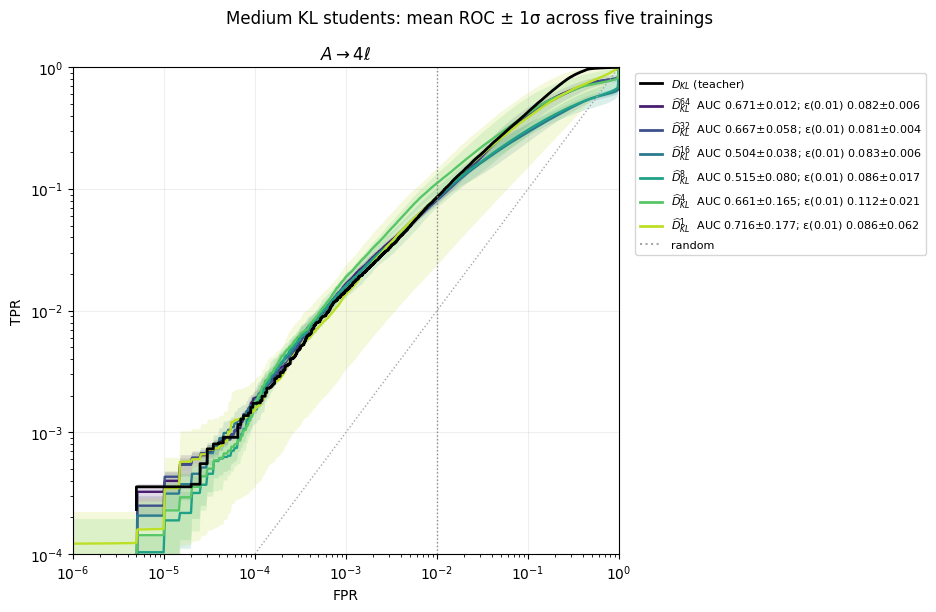

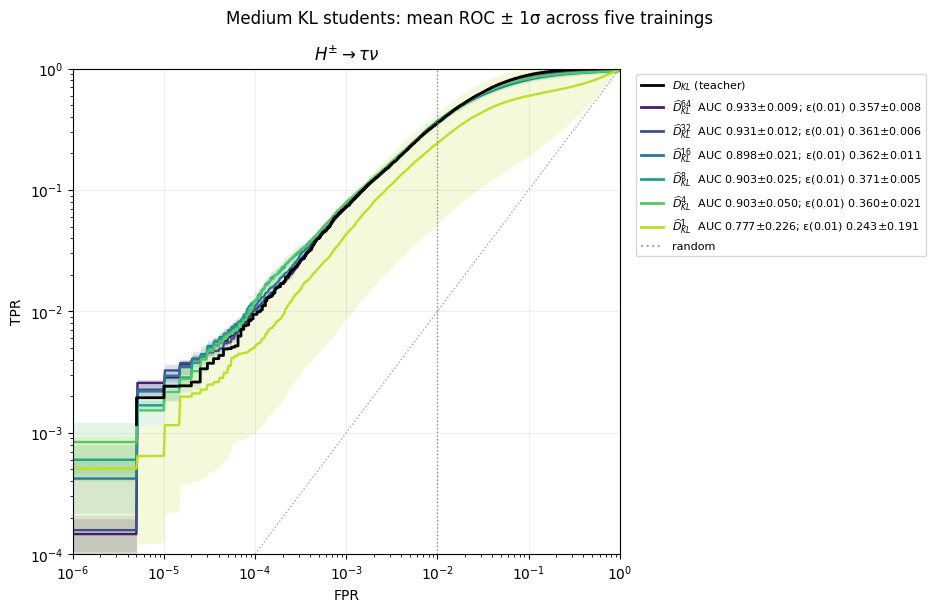

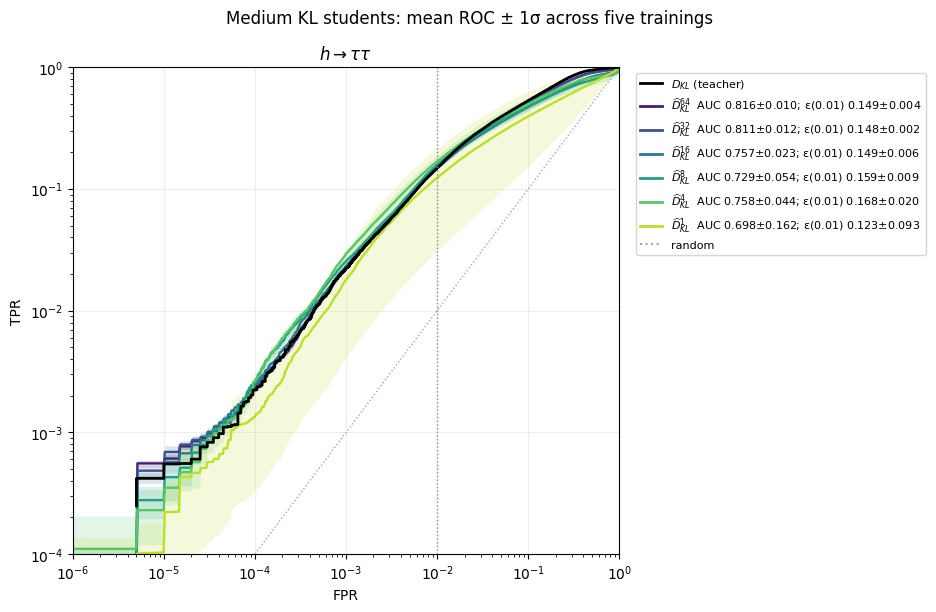

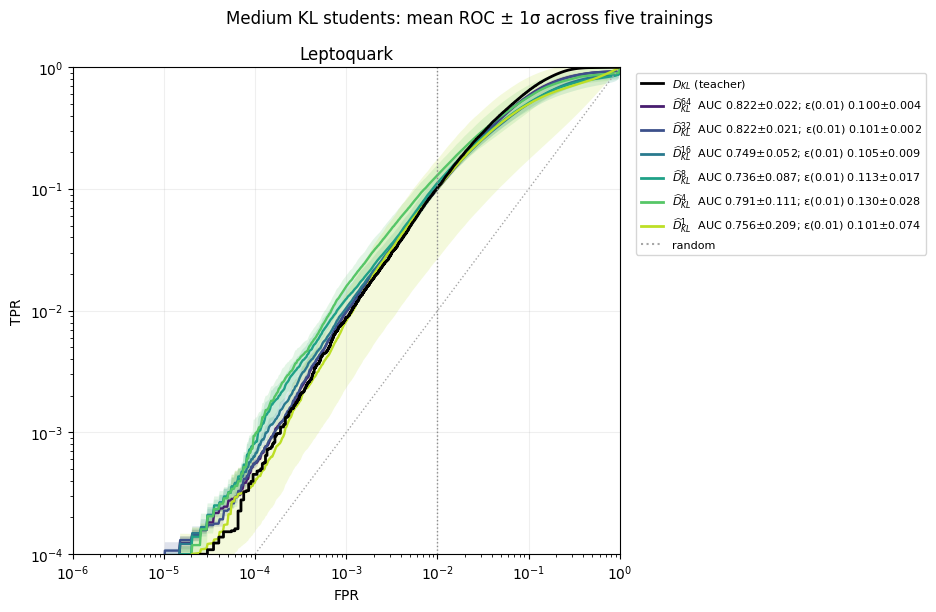

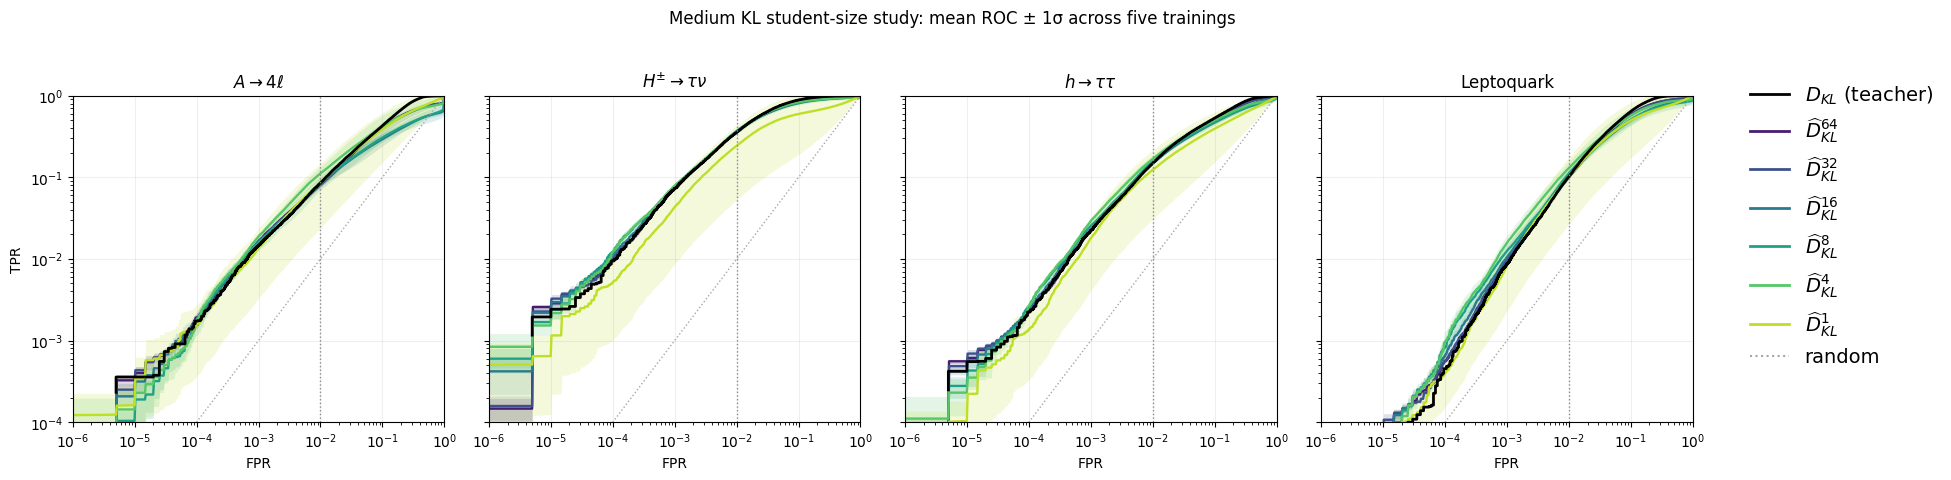

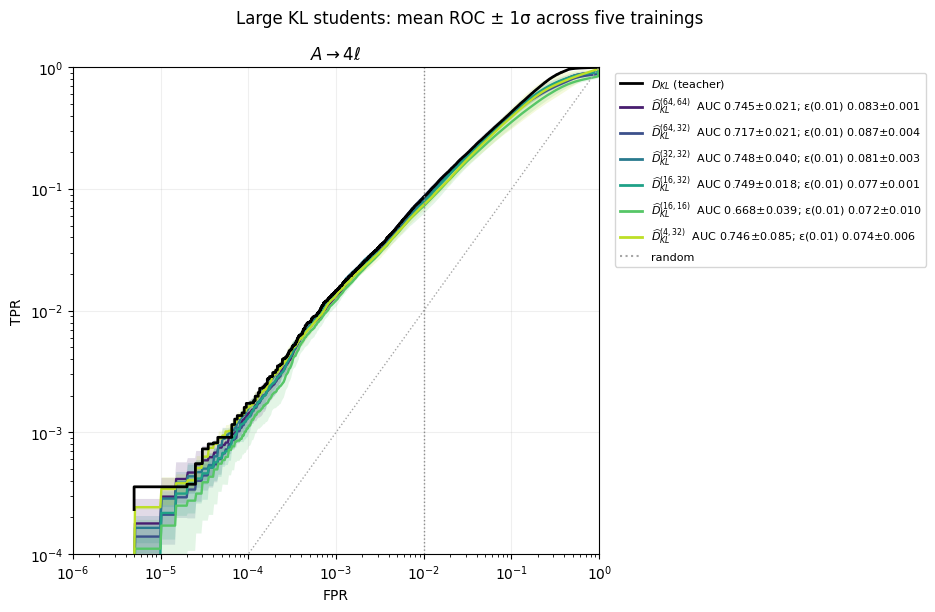

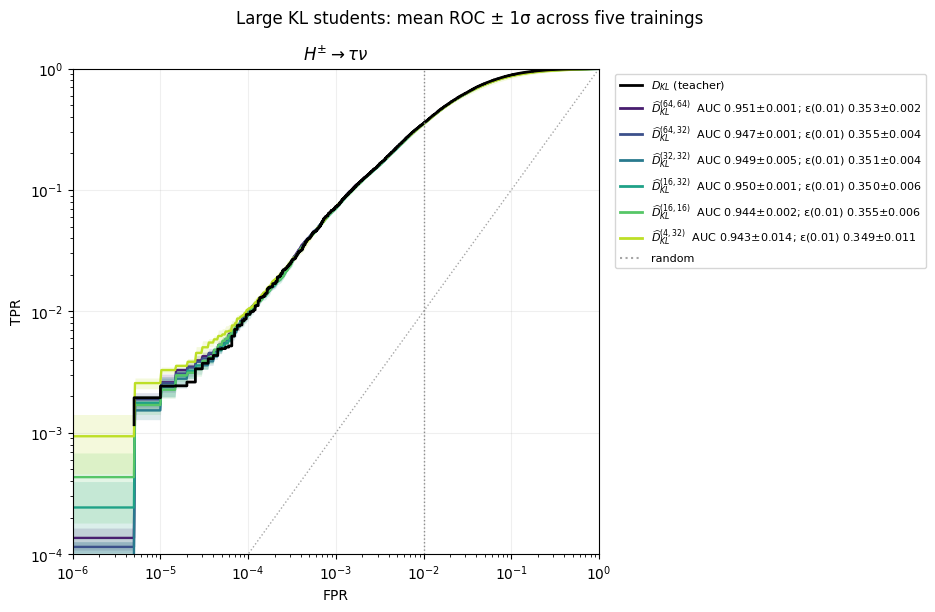

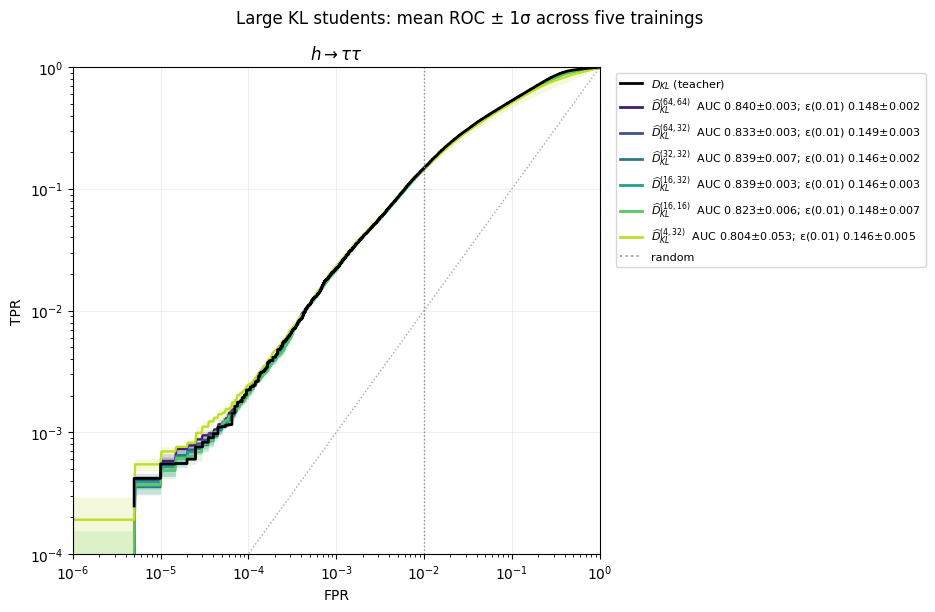

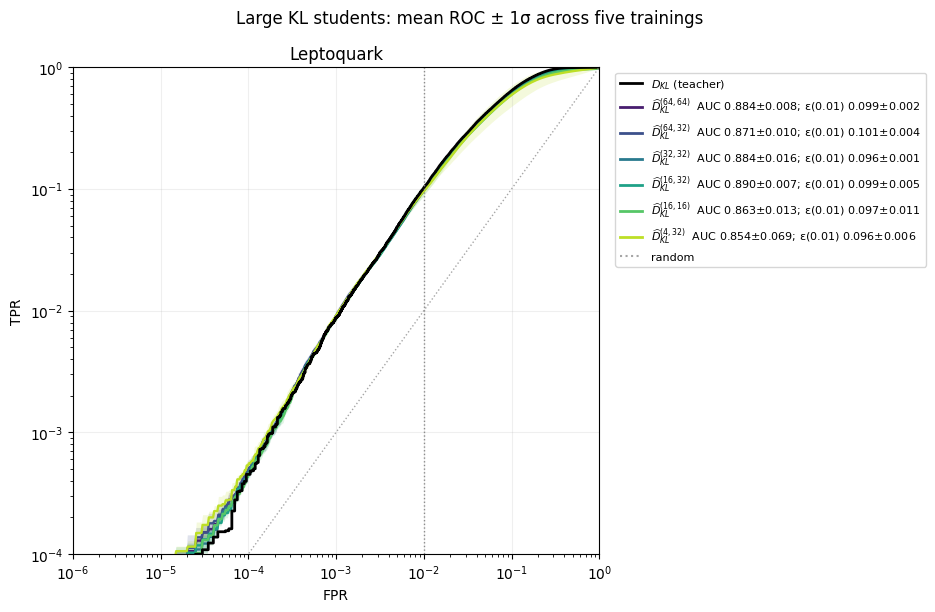

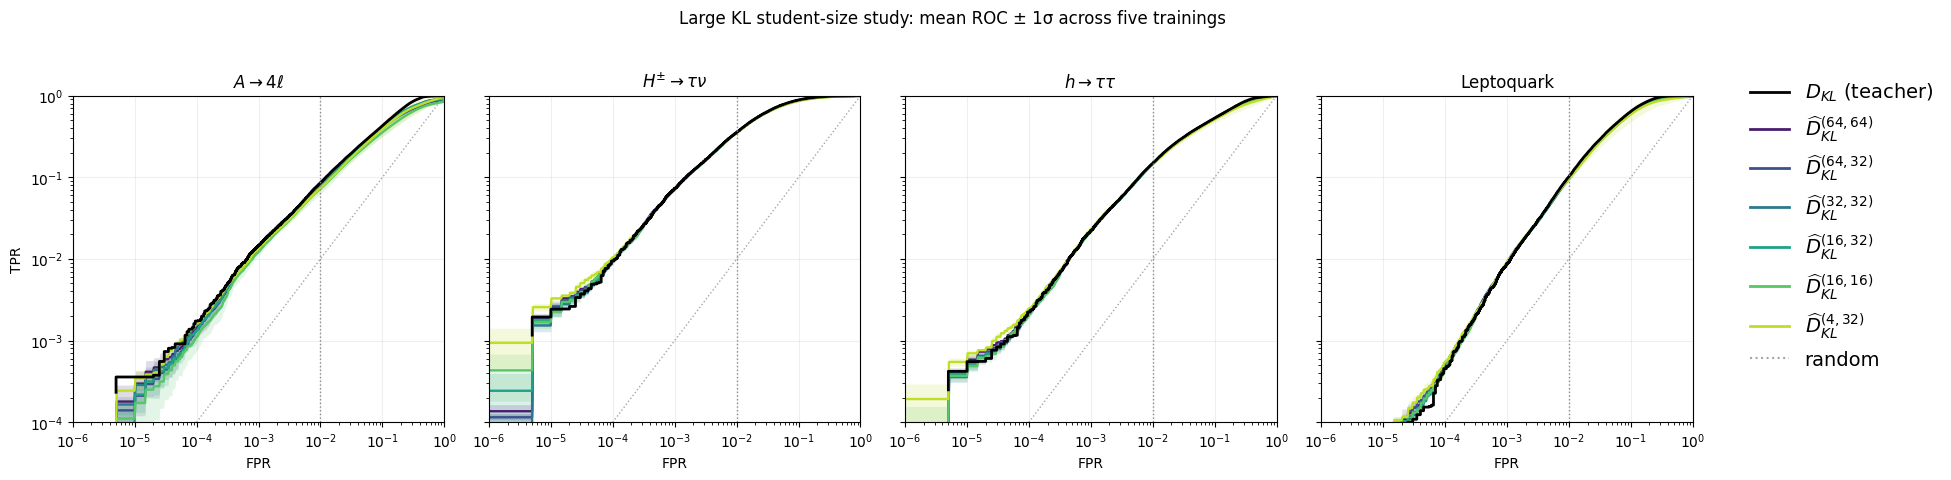

In [29]:
# First run: use "train" to fit all five seeds per width. Afterwards switch to "load".
STUDY_2_MODE = "load"
SIZE_STUDY_TARGET = "KL"
INCLUDE_TEACHER_IN_ROCS = True

if SIZE_STUDY_TARGET != "KL":
    raise ValueError("The student-size study must use the KL target.")

size_models, size_scores = run_size_study(STUDY_2_MODE, SIZE_STUDY_TARGET)
plot_size_rocs(size_scores, SIZE_STUDY_TARGET, include_teacher=INCLUDE_TEACHER_IN_ROCS)

In [26]:
from matplotlib.colors import LogNorm, Normalize


def _score_metric_summary(replicate_scores, signal_tag):
    efficiencies = []
    aucs = []
    for scores_by_tag in replicate_scores:
        fpr, tpr, roc_auc = _roc_values(
            scores_by_tag["Background"], scores_by_tag[signal_tag]
        )
        efficiencies.append(np.interp(REFERENCE_FPR, fpr, tpr))
        aucs.append(roc_auc)
    return (
        np.mean(efficiencies), np.std(efficiencies),
        np.mean(aucs), np.std(aucs),
    )


def plot_size_score_histograms(size_scores, target_name, family, representative_index=0):
    """Stack teacher/representative distributions with five-seed metric summaries."""
    architecture_scores = size_scores[family]
    tags = ["Background", *SIGNAL_TAGS]
    colors = dict(zip(tags, plt.cm.tab10.colors[:len(tags)]))
    teacher_key = TARGET_KEYS[target_name]
    teacher_scores = {tag: datasets[tag][teacher_key] for tag in tags}

    # As in the reference plot: teacher first, then students become smaller downward.
    architecture_order = _ordered_architectures(family, architecture_scores, largest_first=True)
    rows = [(r"teacher $D_{KL}$", [teacher_scores], teacher_scores)]
    for architecture in architecture_order:
        replicates = architecture_scores[architecture]
        if not 0 <= representative_index < len(replicates):
            raise IndexError("representative_index is outside the available student seeds")
        rows.append((rf"$\widehat{{D}}_{{KL}}^{{{architecture}}}$", replicates, replicates[representative_index]))

    percentile_ranges = []
    for _, _, displayed_scores in rows:
        for tag in tags:
            finite = displayed_scores[tag][np.isfinite(displayed_scores[tag])]
            percentile_ranges.append(np.percentile(finite, [0.2, 90]))
    low = min(bounds[0] for bounds in percentile_ranges)
    high = max(bounds[1] for bounds in percentile_ranges)
    bins = np.linspace(low, high, 90)

    epsilon_mean = np.zeros((len(rows), len(SIGNAL_TAGS)))
    epsilon_std = np.zeros_like(epsilon_mean)
    auc_mean = np.zeros_like(epsilon_mean)
    auc_std = np.zeros_like(epsilon_mean)
    for row_index, (_, replicates, _) in enumerate(rows):
        for signal_index, signal_tag in enumerate(SIGNAL_TAGS):
            values = _score_metric_summary(replicates, signal_tag)
            epsilon_mean[row_index, signal_index] = values[0]
            epsilon_std[row_index, signal_index] = values[1]
            auc_mean[row_index, signal_index] = values[2]
            auc_std[row_index, signal_index] = values[3]

    fig = plt.figure(figsize=(18, 1.75 * len(rows) + 1.4))
    grid = fig.add_gridspec(
        len(rows), 3,
        width_ratios=(5.4, 1.65, 1.65),
        left=0.08, right=0.94, bottom=0.10, top=0.88,
        hspace=0.08, wspace=0.18,
    )
    distribution_axes = []
    for row_index, (row_label, _, displayed_scores) in enumerate(rows):
        ax = fig.add_subplot(grid[row_index, 0], sharex=distribution_axes[0] if distribution_axes else None)
        distribution_axes.append(ax)
        background = displayed_scores["Background"]
        threshold = np.quantile(background[np.isfinite(background)], 1 - REFERENCE_FPR)

        for tag in tags:
            finite = displayed_scores[tag][np.isfinite(displayed_scores[tag])]
            ax.hist(
                finite,
                bins=bins,
                density=True,
                histtype="step",
                linewidth=1.2,
                color=colors[tag],
                label=tag,
            )
            mean = np.mean(finite)
            sigma = np.std(finite)
            ax.axvline(mean, color=colors[tag], linestyle="--", linewidth=0.9, alpha=0.8)
            ax.axvline(mean - sigma, color=colors[tag], linestyle=":", linewidth=0.7, alpha=0.65)
            ax.axvline(mean + sigma, color=colors[tag], linestyle=":", linewidth=0.7, alpha=0.65)

        ax.axvline(threshold, color="0.2", linestyle="-.", linewidth=1.0)
        ax.set_ylabel(row_label, rotation=0, ha="right", va="center", labelpad=12, fontsize=18)
        ax.set_xlim(low, high)
        ax.grid(True, alpha=0.16)
        if row_index != len(rows) - 1:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel(f"Score (regressed to {target_name})", fontsize=14)

    legend_handles = [
        Line2D([0], [0], color=colors[tag], linewidth=1.4, label=SIGNAL_LABELS.get(tag, tag))
        for tag in tags
    ]
    legend_handles.extend([
        Line2D([0], [0], color="0.3", linestyle="--", label="mean"),
        Line2D([0], [0], color="0.3", linestyle=":", label=r"mean $\pm\sigma$"),
        Line2D([0], [0], color="0.2", linestyle="-.", label="threshold at FPR=0.01"),
    ])
    distribution_axes[0].legend(
        handles=legend_handles,
        ncol=4,
        fontsize=14,
        loc="lower left",
        bbox_to_anchor=(0, 1.02),
        frameon=False,
    )

    epsilon_ax = fig.add_subplot(grid[:, 1])
    auc_ax = fig.add_subplot(grid[:, 2])
    epsilon_floor = max(1e-4, np.min(epsilon_mean[epsilon_mean > 0]))
    epsilon_image = epsilon_ax.imshow(
        np.clip(epsilon_mean, epsilon_floor, 1),
        aspect="auto",
        cmap="viridis",
        norm=LogNorm(vmin=epsilon_floor, vmax=1),
    )
    auc_image = auc_ax.imshow(
        auc_mean,
        aspect="auto",
        cmap="magma",
        norm=Normalize(vmin=0.5, vmax=1.0),
    )

    short_signal_labels = [SIGNAL_LABELS.get(tag, tag) for tag in SIGNAL_TAGS]
    for metric_ax, title in ((epsilon_ax, r"$\epsilon_S$ @ FPR=0.01"), (auc_ax, "AUC")):
        metric_ax.set_title(title, fontsize=14, pad=8)
        metric_ax.set_xticks(range(len(SIGNAL_TAGS)), short_signal_labels, rotation=35, ha="right", fontsize=12)
        metric_ax.set_yticks(range(len(rows)))
        metric_ax.set_yticklabels([])
        metric_ax.tick_params(length=0)

    for row_index in range(len(rows)):
        for signal_index in range(len(SIGNAL_TAGS)):
            epsilon_ax.text(
                signal_index,
                row_index,
                f"{100 * epsilon_mean[row_index, signal_index]:.2f}%\n"
                f"± {100 * epsilon_std[row_index, signal_index]:.2f}%",
                ha="center",
                va="center",
                fontsize=7,
                color="black" if epsilon_mean[row_index, signal_index] > 0.08 else "white",
            )
            auc_ax.text(
                signal_index,
                row_index,
                f"{100 * auc_mean[row_index, signal_index]:.1f}%\n"
                f"± {100 * auc_std[row_index, signal_index]:.2f}%",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if auc_mean[row_index, signal_index] < 0.82 else "black",
            )

    epsilon_colorbar = fig.colorbar(epsilon_image, ax=epsilon_ax, fraction=0.06, pad=0.04)
    auc_colorbar = fig.colorbar(auc_image, ax=auc_ax, fraction=0.06, pad=0.04)
    epsilon_colorbar.set_label(r"$\epsilon_S$", fontsize=14)
    auc_colorbar.set_label("AUC", fontsize=14)
    fig.suptitle(
        f"{family.capitalize()} KL students: distributions and five-training performance",
        fontsize=13,
    )
    plt.show()

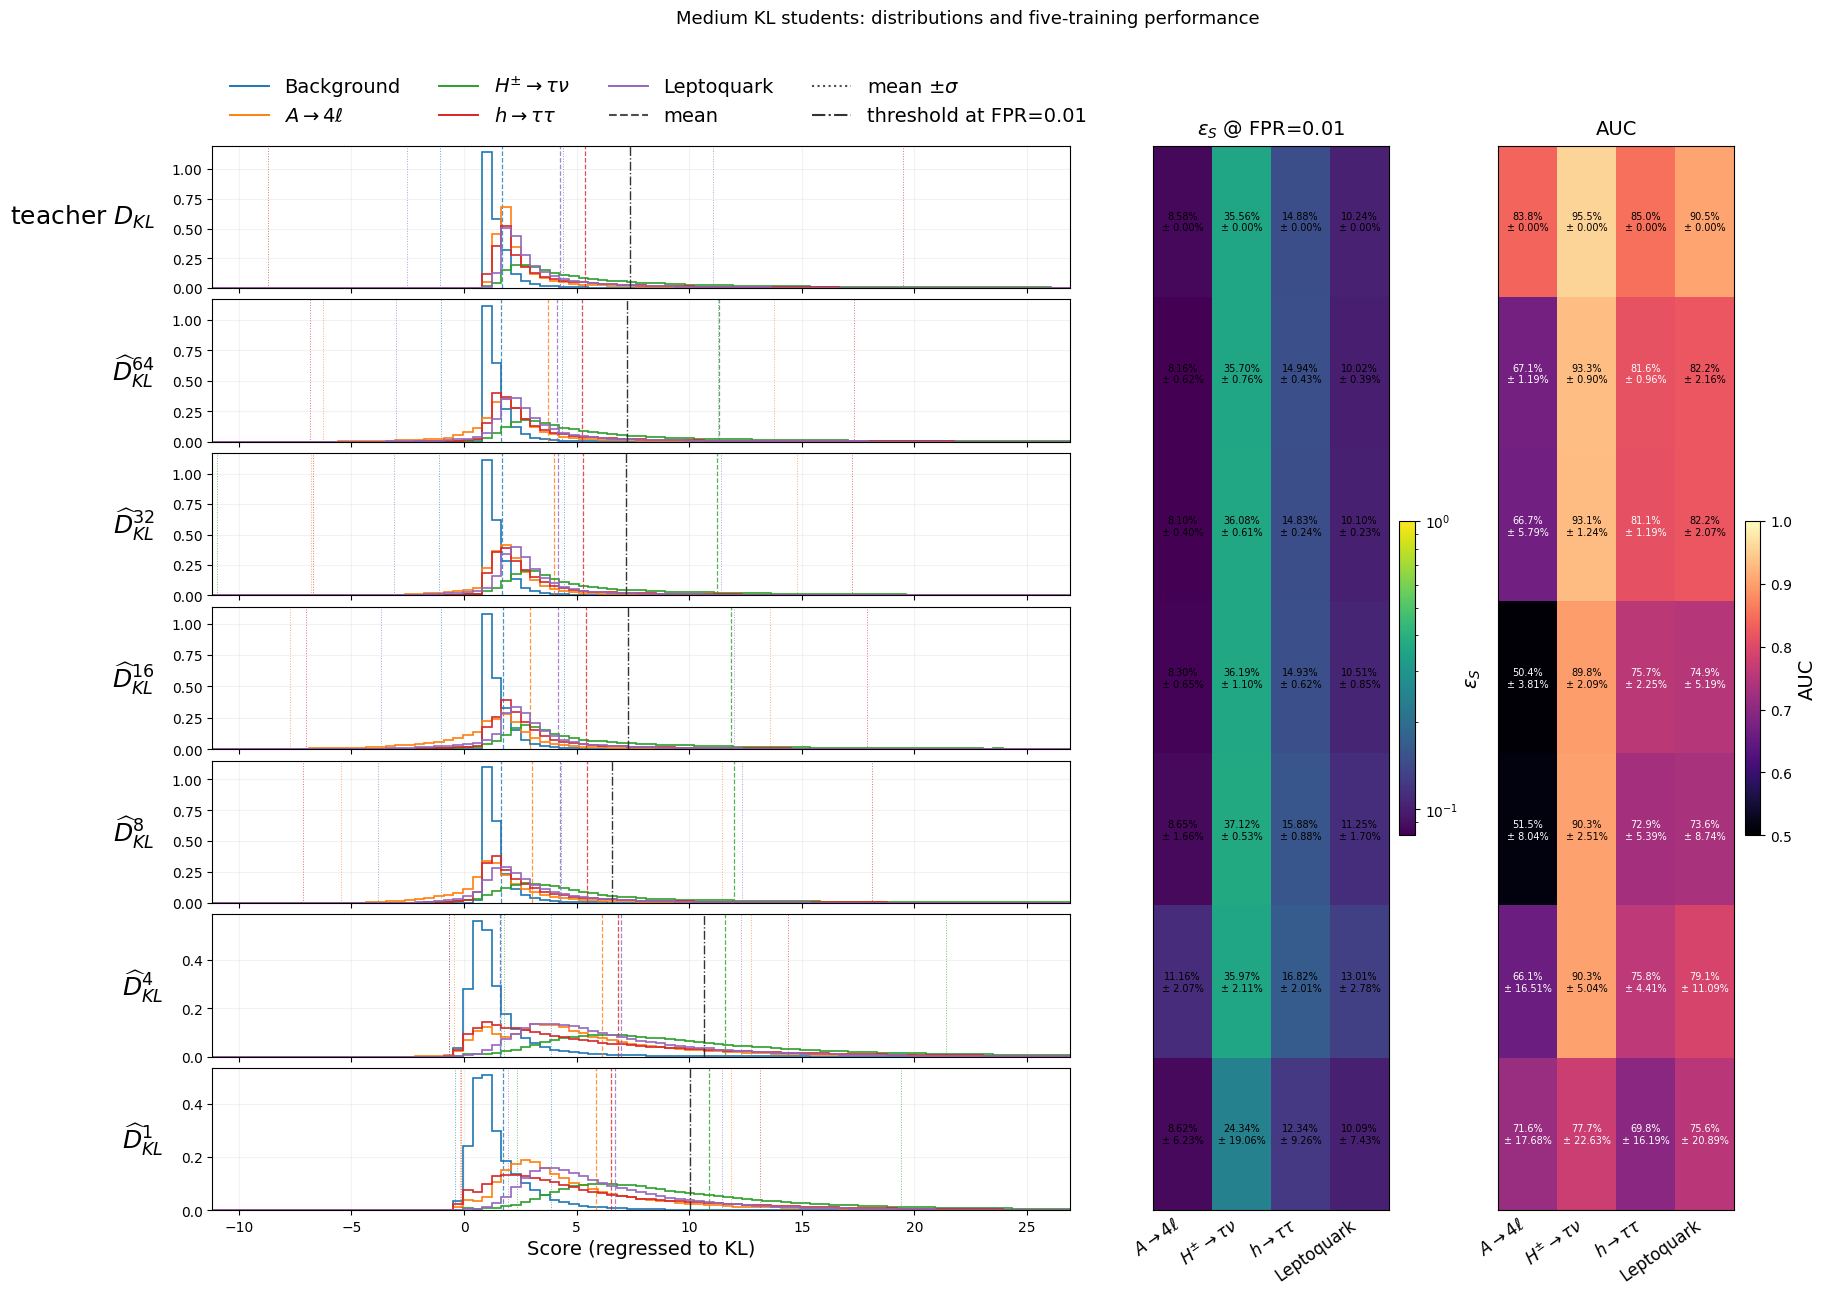

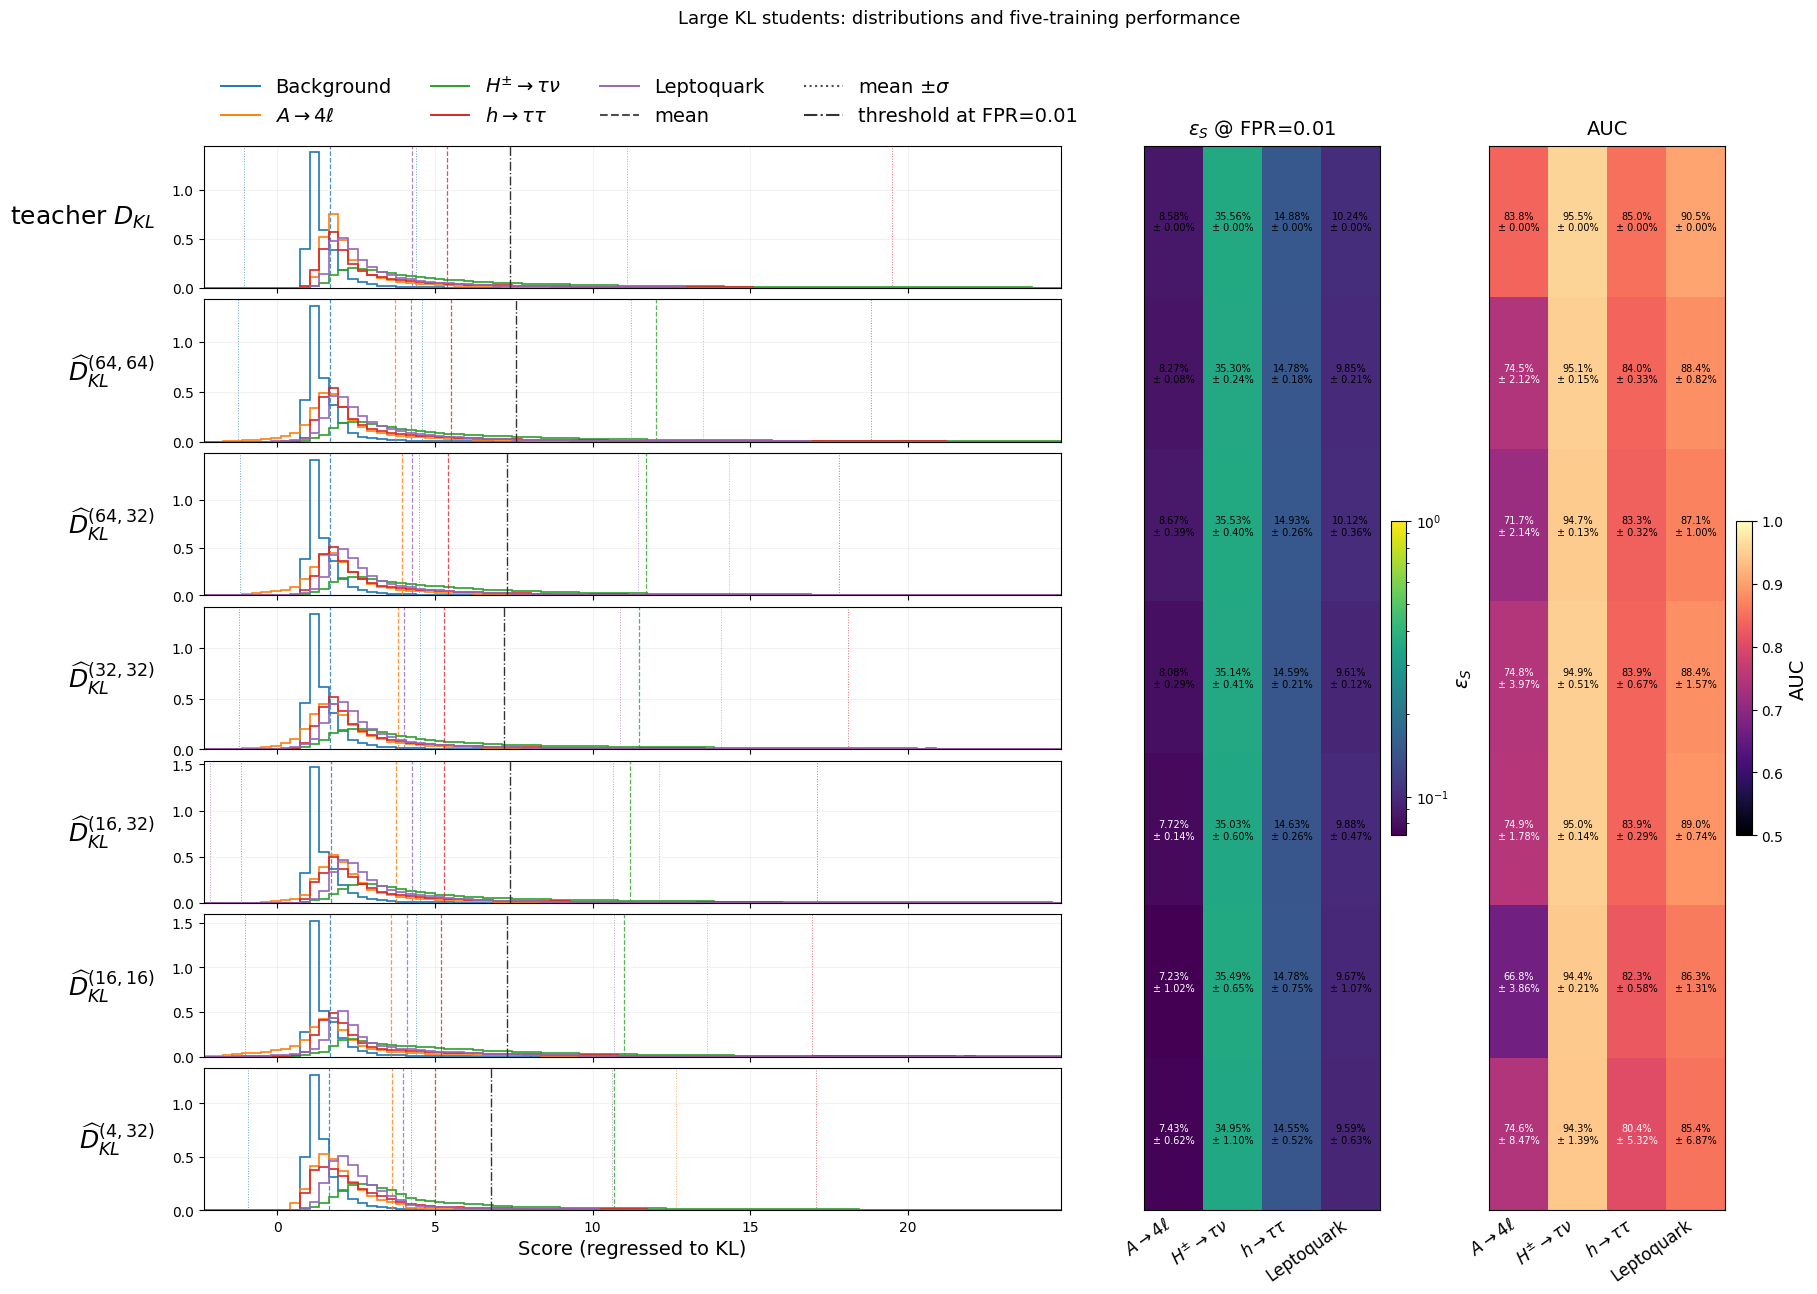

In [27]:
# Run Study 2 first to reuse its in-memory predictions; otherwise load all five seeds.
STUDY_3_MODE = "load"
HISTOGRAM_TARGET = "KL"
REPRESENTATIVE_STUDENT_INDEX = 0

if HISTOGRAM_TARGET != "KL":
    raise ValueError("The student-size study must use the KL target.")

if (
    "size_scores" in globals()
    and HISTOGRAM_TARGET == globals().get("SIZE_STUDY_TARGET")
):
    histogram_scores = size_scores
else:
    histogram_models, histogram_scores = run_size_study(STUDY_3_MODE, HISTOGRAM_TARGET)

plot_size_score_histograms(
    histogram_scores, HISTOGRAM_TARGET, "medium", REPRESENTATIVE_STUDENT_INDEX
)
plot_size_score_histograms(
    histogram_scores, HISTOGRAM_TARGET, "large", REPRESENTATIVE_STUDENT_INDEX
)